<h1>在newmove底下建資料夾

In [1]:
import os
import shutil

def copy_frames_in_groups(source_base_dir, target_base_dir, group_size=20):
    # 確保目標資料夾存在
    if not os.path.exists(target_base_dir):
        os.makedirs(target_base_dir)

    # 模擬資料夾結構，定義各資料夾的範圍
    segments = {
        "2": [(54, 173)],
        "4": [(857, 1007)],
        "5": [(2703, 2894), (3838, 4047)],
        "6": [(521, 766)],
        "7": [(119, 268)],
        "9": [(0, 251)],
        "10": [(0, 270)],
        "11": [(793, 865)],
        "14": [(2332, 2360)],
        "15": [(4192, 4221), (4662, 4785), (6155, 6201), (8334, 8422), (12609, 12630)],
        "16": [(690, 1130)],
        "17": [(0, 270), (845, 940)],
        "19": [(496, 566), (1000, 1040)],
        "22": [(227, 285)],
        "23": [(140, 242)],
        "24": [(200, 496)],
        "27": [(1462, 1505), (2000, 2283)],
        "28": [(831, 883), (946, 1002), (1003, 1116)],
        "30": [(148, 282)],
    }

    # 資料夾計數器
    total_folders = 0
    total_frames = 0

    # 記錄新資料夾的編號
    new_folder_id = 1

    # 遍歷所有資料夾和片段進行分組複製 frame
    for folder_name, ranges in segments.items():
        for start_frame, end_frame in ranges:
            # 使用滑動窗口進行分組
            for i in range(start_frame, end_frame - 19 + 1):  # 使用 end_frame - 19 + 1
                group_folder = os.path.join(target_base_dir, f"{new_folder_id}")
                os.makedirs(group_folder, exist_ok=True)

                # 從來源資料夾中取每組的 20 張 frame
                for j in range(group_size):
                    frame_number = i + j
                    frame_filename = f"frame{frame_number}.bmp"  # 使用 .bmp 格式
                    source_path = os.path.join(source_base_dir, folder_name, frame_filename)
                    
                    # 確認 frame 存在後進行複製
                    if os.path.exists(source_path):
                        shutil.copy(source_path, os.path.join(group_folder, frame_filename))
                    else:
                        print(f"Warning: {source_path} not found.")

                # 每創建一組資料夾，增加總資料夾數和總frame數
                total_folders += 1
                total_frames += group_size
                new_folder_id += 1  # 更新資料夾編號

    # 檢查最後一個資料夾是否來自 picture/30 的 frame263 到 frame282
    last_group_folder = os.path.join(target_base_dir, f"{new_folder_id - 1}")
    if os.path.exists(last_group_folder):
        print(f"The last group folder {last_group_folder} is correct.")
    else:
        print("Warning: The last group folder is incorrect.")

    # 最後輸出資料夾數量與總frame數量
    print(f"Total number of folders: {total_folders}")
    print(f"Total number of frames: {total_frames}")


if __name__ == "__main__":
    source_base_dir = r"D:\nchu\picture"  # 來源資料夾
    target_base_dir = r"D:\nchu\newmove"  # 目標資料夾
    copy_frames_in_groups(source_base_dir, target_base_dir)


The last group folder D:\nchu\newmove\3521 is correct.
Total number of folders: 3521
Total number of frames: 70420


<h1>將影片切成影像

In [ ]:
import cv2
from tqdm import tqdm

def extractImages(pathIn, pathOut,time_F):
    vidcap = cv2.VideoCapture(pathIn)
    
    count = 0
    c=1
    if vidcap.isOpened(): #判斷是否開啟影片
        success, image = vidcap.read()
    else:
        success = False
        
    while success:
        success,image = vidcap.read()
        if success==False:
            break
        if(c % time_F == 0 ) :
            cv2.imwrite( pathOut + "\\frame%d.bmp" % count, image)     # save frame  as image
            count += 1
        c+=1
        cv2.waitKey()
    vidcap.release()
    
    
#分割影片
pathin = r"D:\nchu\newvideos"
pathout = r"D:\nchu\picture\Cutvideo"
for i in tqdm(range(25,33)):
    extractImages(pathin+"\\%d.mp4" % (i), pathout+"\\%d" % i, 1)

<h1>將影像轉標準差取最大值_優化

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

pathin = r"D:\nchu\newmove"
# pathin = r"D:\\nchu\\move"
pathout = r"D:\\nchu\\RGBstd\\maxstd2"

idx_list = [i for i in range(1, 1189)]

for i in tqdm(idx_list):
    # 取得影像檔名列表
    name = os.listdir(os.path.join(pathin, str(i)))

    # 讀取所有影像並存入陣列
    arr = np.array([cv2.imread(os.path.join(pathin, str(i), pic)) for pic in name])

    # 正規化至 [0, 1] 範圍
    arr = arr / 255.0

    # 計算每個通道的標準差
    std_B = np.std(arr[:, :, :, 0], axis=0) * 255
    std_G = np.std(arr[:, :, :, 1], axis=0) * 255
    std_R = np.std(arr[:, :, :, 2], axis=0) * 255

    # 計算最大值影像
    imgmax = np.maximum.reduce([std_B, std_G, std_R])

    # 儲存結果影像
    cv2.imwrite(os.path.join(pathout, f"maxstd{i}.bmp"), imgmax.astype(np.uint8))


<h1>強化區域方式使用距離(與圓心距離)window size = 15 (寫死的如果要用其他window size要改)_優化

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

window = 15
pathin = r"D:\\nchu\\RGBstd\\maxstd2"
pathout = r"D:\\nchu\\RGBstd_SR\\distance\\window=%s" % window
os.makedirs(pathout + "/newno", exist_ok=True)

idx_list = sorted([int(i.split(".")[0].split("d")[1]) for i in os.listdir(pathin)])

# 指定開始的索引（包含）
start_idx = 1189
idx_list = [idx for idx in idx_list if idx >= start_idx]
print(f"從第 {start_idx} 張開始，總共需要處理 {len(idx_list)} 張圖像。")

for pic_idx in tqdm(idx_list):
    img = cv2.imread(f"{pathin}/maxstd{pic_idx}.bmp", cv2.IMREAD_GRAYSCALE)
    afterimg = img.astype(np.float32).copy()

    # 將圖像擴展邊界
    padded_img = np.pad(img, pad_width=window // 2, mode='constant', constant_values=0)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            weighted_sum = 0
            for distance in range(1, (window // 2) + 1):
                # 提取該距離的像素
                neighbors = [
                    padded_img[y + window // 2, x + window // 2 + distance],  # 右
                    padded_img[y + window // 2, x + window // 2 - distance],  # 左
                    padded_img[y + window // 2 + distance, x + window // 2],  # 下
                    padded_img[y + window // 2 - distance, x + window // 2],  # 上
                    padded_img[y + window // 2 + distance, x + window // 2 + distance],  # 右下
                    padded_img[y + window // 2 - distance, x + window // 2 + distance],  # 右上
                    padded_img[y + window // 2 + distance, x + window // 2 - distance],  # 左下
                    padded_img[y + window // 2 - distance, x + window // 2 - distance],  # 左上
                ]
                # 過濾無效值，計算當前距離的平均值
                valid_neighbors = [v for v in neighbors if v > 0]
                if valid_neighbors:
                    avg_value = sum(valid_neighbors) / len(valid_neighbors)
                    weighted_sum += avg_value / distance

            afterimg[y, x] += weighted_sum

    # 儲存結果
    cv2.imwrite(f"{pathout}/newno/w{window}SR{pic_idx}.bmp", afterimg.astype(np.uint8))


<h1>將強化區域後拉到0-255_優化

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

pathin = r"D:\nchu\RGBstd_SR\distance\window=15\newno"
pathout = r"D:\nchu\RGBstd_SR\distance\window=15"
gamma_list = [1]  # Gamma list remains the same, can add other values if needed
window_list = [15]

# Get the sorted indices of files
start_idx = 1191
end_idx = 3521
idx_list = sorted([int(i.split(".")[0].split("R")[1]) for i in os.listdir(pathin) if i.endswith(".bmp") and start_idx <= int(i.split(".")[0].split("R")[1]) <= end_idx])
print(len(idx_list))

# Precompute gamma adjustment if gamma > 1
for window in window_list:
    for gamma in gamma_list:
        for pic_idx in tqdm(idx_list):
            input_file = os.path.join(pathin, f"w{window}SR{pic_idx}.bmp")
            img = cv2.imread(input_file, cv2.IMREAD_GRAYSCALE)

            # Min-Max normalization and gamma correction
            total_min, total_max, _, _ = cv2.minMaxLoc(img)
            img_normalized = (img - total_min) / (total_max - total_min)
            img_corrected = np.power(img_normalized, gamma) * 255
            img_corrected = img_corrected.astype(np.uint8)

            # output_file = os.path.join(pathout, f"afternewno/w{window}SR{pic_idx}.bmp")
            output_file = os.path.join(pathout, f"afternewno/{pic_idx}.bmp")
            cv2.imwrite(output_file, img_corrected)


<h1>生成灰階影像

In [1]:
import os
from PIL import Image

def convert_first_frame_to_gray(input_base_dir, output_base_dir, start_idx, end_idx):
    # 確保輸出資料夾存在
    if not os.path.exists(output_base_dir):
        os.makedirs(output_base_dir)

    # 遍歷所有子資料夾
    for folder_name in os.listdir(input_base_dir):
        folder_path = os.path.join(input_base_dir, folder_name)
        
        # 確保是資料夾且名稱為數字且在指定範圍內
        if os.path.isdir(folder_path) and folder_name.isdigit():
            folder_idx = int(folder_name)
            if start_idx <= folder_idx <= end_idx:
                # 找到子資料夾中的所有 .bmp 檔案
                bmp_files = [f for f in os.listdir(folder_path) if f.endswith('.bmp')]
                if not bmp_files:
                    print(f"No BMP files found in {folder_path}. Skipping...")
                    continue

                # 按檔名中的數字排序，找到最小的檔案
                bmp_files.sort(key=lambda x: int(x.replace('frame', '').replace('.bmp', '')))
                first_frame = bmp_files[0]  # 第一張影像
                first_frame_path = os.path.join(folder_path, first_frame)

                # 讀取影像並轉換為灰階
                try:
                    with Image.open(first_frame_path) as img:
                        gray_img = img.convert("L")  # 轉換為灰階

                        # 將灰階影像輸出至指定資料夾
                        output_file_name = f"{folder_name}.bmp"  # 命名為子資料夾名稱.bmp
                        output_path = os.path.join(output_base_dir, output_file_name)
                        gray_img.save(output_path)
                        print(f"Saved gray image: {output_path}")
                except Exception as e:
                    print(f"Error processing {first_frame_path}: {e}")

if __name__ == "__main__":
    input_base_dir = r"D:\nchu\newmove"  # 子資料夾所在目錄
    output_base_dir = r"D:\nchu\picture\Gray_folder"  # 灰階影像輸出目錄
    
    # 指定要處理的子資料夾範圍
    start_idx = 1189
    end_idx = 3521
    
    convert_first_frame_to_gray(input_base_dir, output_base_dir, start_idx, end_idx)


Saved gray image: D:\nchu\picture\Gray_folder\1189.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1190.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1191.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1192.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1193.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1194.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1195.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1196.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1197.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1198.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1199.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1200.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1201.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1202.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1203.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1204.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1205.bmp
Saved gray image: D:\nchu\picture\Gray_folder\1206.bmp
Saved gray

<h1>Enhanced_Gray_folder

In [3]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# 修改後的路徑
pathin = r"D:\nchu\picture\Gray_folder"  # 輸入資料夾
pathout = r"D:\nchu\picture\Enhanced_Gray_folder"  # 輸出資料夾

gamma_list = [1]  # Gamma list remains the same, can add other values if needed

# Get all .bmp files in the input folder
bmp_files = [f for f in os.listdir(pathin) if f.endswith(".bmp")]
print(f"Total BMP files found: {len(bmp_files)}")

# Create the output folder if it doesn't exist
if not os.path.exists(pathout):
    os.makedirs(pathout)

# Precompute gamma adjustment if gamma > 1
for gamma in gamma_list:
    for bmp_file in tqdm(bmp_files, desc="Processing files"):
        input_file = os.path.join(pathin, bmp_file)
        img = cv2.imread(input_file, cv2.IMREAD_GRAYSCALE)

        # Min-Max normalization and gamma correction
        total_min, total_max, _, _ = cv2.minMaxLoc(img)
        img_normalized = (img - total_min) / (total_max - total_min)
        img_corrected = np.power(img_normalized, gamma) * 255
        img_corrected = img_corrected.astype(np.uint8)

        # Save the processed image with the same filename in the output folder
        output_file = os.path.join(pathout, bmp_file)
        cv2.imwrite(output_file, img_corrected)


Total BMP files found: 3521


Processing files: 100%|██████████| 3521/3521 [01:41<00:00, 34.83it/s]


<h1>抓出原始影像

In [1]:
import os
from PIL import Image

def copy_first_frame(input_base_dir, output_base_dir):
    # 確保輸出資料夾存在
    if not os.path.exists(output_base_dir):
        os.makedirs(output_base_dir)

    # 遍歷所有子資料夾
    for folder_name in os.listdir(input_base_dir):
        folder_path = os.path.join(input_base_dir, folder_name)
        if os.path.isdir(folder_path):  # 確保是資料夾
            # 找到子資料夾中的所有 .bmp 檔案
            bmp_files = [f for f in os.listdir(folder_path) if f.endswith('.bmp')]
            if not bmp_files:
                print(f"No BMP files found in {folder_path}. Skipping...")
                continue

            # 按檔名中的數字排序，找到最小的檔案
            bmp_files.sort(key=lambda x: int(x.replace('frame', '').replace('.bmp', '')))
            first_frame = bmp_files[0]  # 第一張影像
            first_frame_path = os.path.join(folder_path, first_frame)

            # 直接複製原始影像到指定資料夾
            try:
                with Image.open(first_frame_path) as img:
                    output_file_name = f"{folder_name}.bmp"  # 命名為子資料夾名稱.bmp
                    output_path = os.path.join(output_base_dir, output_file_name)
                    img.save(output_path)
                    print(f"Saved original image: {output_path}")
            except Exception as e:
                print(f"Error processing {first_frame_path}: {e}")

if __name__ == "__main__":
    input_base_dir = r"D:\\nchu\\newmove"  # 子資料夾所在目錄
    output_base_dir = r"D:\\nchu\\test_project"  # 原始影像輸出目錄
    copy_first_frame(input_base_dir, output_base_dir)


Saved original image: D:\\nchu\\test_project\1.bmp
Saved original image: D:\\nchu\\test_project\10.bmp
Saved original image: D:\\nchu\\test_project\100.bmp
Saved original image: D:\\nchu\\test_project\1000.bmp
Saved original image: D:\\nchu\\test_project\1001.bmp
Saved original image: D:\\nchu\\test_project\1002.bmp
Saved original image: D:\\nchu\\test_project\1003.bmp
Saved original image: D:\\nchu\\test_project\1004.bmp
Saved original image: D:\\nchu\\test_project\1005.bmp
Saved original image: D:\\nchu\\test_project\1006.bmp
Saved original image: D:\\nchu\\test_project\1007.bmp
Saved original image: D:\\nchu\\test_project\1008.bmp
Saved original image: D:\\nchu\\test_project\1009.bmp
Saved original image: D:\\nchu\\test_project\101.bmp
Saved original image: D:\\nchu\\test_project\1010.bmp
Saved original image: D:\\nchu\\test_project\1011.bmp
Saved original image: D:\\nchu\\test_project\1012.bmp
Saved original image: D:\\nchu\\test_project\1013.bmp
Saved original image: D:\\nchu\\tes

<h1>生成光流圖(Optical flow)

In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

# 指定父資料夾路徑
parent_folder = 'D:\\nchu\\newmove'
output_folder = 'D:\\nchu\\picture\\optical_flow_results'

# 確保父資料夾存在
if not os.path.exists(parent_folder):
    print(f"Error: 資料夾 {parent_folder} 不存在！")
    exit()

# 確保輸出資料夾存在
os.makedirs(output_folder, exist_ok=True)

# 遍歷所有子資料夾
subfolders = [os.path.join(parent_folder, d) for d in os.listdir(parent_folder) if os.path.isdir(os.path.join(parent_folder, d))]

for subfolder in tqdm(subfolders, desc="Processing subfolders"):
    # 找到子資料夾中的所有 .bmp 檔案
    bmp_files = [f for f in os.listdir(subfolder) if f.startswith('frame') and f.endswith('.bmp')]

    # 提取檔名中的數字並排序
    sorted_files = sorted(bmp_files, key=lambda x: int(x[5:-4]))  # 提取 'frame' 之後的數字並排序

    if len(sorted_files) < 2:
        print(f"Warning: 資料夾 {subfolder} 中檔案數不足兩張！")
        continue

    # 取數字最小的兩張檔案
    file1 = os.path.join(subfolder, sorted_files[0])
    file2 = os.path.join(subfolder, sorted_files[1])

    # 讀取影像
    img1 = cv2.imread(file1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(file2, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print(f"Error: 無法讀取檔案 {file1} 或 {file2}！")
        continue

    # 計算光流
    flow = cv2.calcOpticalFlowFarneback(img1, img2, None,
                                        pyr_scale=0.5, levels=3, winsize=15,
                                        iterations=3, poly_n=5, poly_sigma=1.2, flags=0)

    # 將光流轉換為 HSV 格式以便可視化
    magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv = np.zeros((img1.shape[0], img1.shape[1], 3), dtype=np.uint8)
    hsv[..., 1] = 255
    hsv[..., 0] = angle * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

    # HSV 轉換為 BGR 格式
    flow_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # 取得子資料夾名稱作為結果檔案名稱
    subfolder_name = os.path.basename(subfolder)
    output_path = os.path.join(output_folder, f"{subfolder_name}.bmp")

    # 儲存結果
    cv2.imwrite(output_path, flow_bgr)


Processing subfolders: 100%|██████████| 3521/3521 [24:40<00:00,  2.38it/s]


<h1>合併三通道

In [ ]:
import os
import cv2
import re
import numpy as np

def natural_sort_key(s):
    """ 取得自然排序的鍵值，確保檔名按照數字大小排序 """
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', s)]

def filter_files_by_range(files, start, end):
    """ 過濾檔案名稱，僅保留指定範圍內的檔案 """
    filtered = []
    for file in files:
        match = re.search(r'(\d+)', file)
        if match:
            num = int(match.group(1))
            if start <= num <= end:
                filtered.append(file)
    return sorted(filtered, key=natural_sort_key)

def merge_images(folder1, folder2, folder3, output_folder, start_idx, end_idx):
    # 確保輸出資料夾存在
    os.makedirs(output_folder, exist_ok=True)

    # 過濾並排序檔案
    files1 = filter_files_by_range(os.listdir(folder1), start_idx, end_idx)
    files2 = filter_files_by_range(os.listdir(folder2), start_idx, end_idx)
    files3 = filter_files_by_range(os.listdir(folder3), start_idx, end_idx)

    merged_count = 0

    for i, (file1, file2, file3) in enumerate(zip(files1, files2, files3), start=start_idx):
        path1, path2, path3 = os.path.join(folder1, file1), os.path.join(folder2, file2), os.path.join(folder3, file3)

        # 讀取影像 (灰階)
        img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
        img3 = cv2.imread(path3, cv2.IMREAD_GRAYSCALE)

        # 確保影像讀取成功
        if img1 is None or img2 is None or img3 is None:
            print(f"跳過 {file1}：無法讀取影像。")
            continue

        # 確保影像尺寸一致
        if img1.shape != img2.shape or img1.shape != img3.shape:
            print(f"跳過 {file1}：影像尺寸不一致 ({img1.shape}, {img2.shape}, {img3.shape})。")
            continue

        # 合併為三通道影像
        merged_img = cv2.merge((img1, img2, img3))

        # 儲存合併後影像，檔名格式為 1189.bmp、1190.bmp...
        output_path = os.path.join(output_folder, f"{i}.bmp")
        cv2.imwrite(output_path, merged_img)
        merged_count += 1

    print(f"成功合併 {merged_count} 張圖片，存入 {output_folder}。")

# 設定資料夾路徑
folder1 = "D:\\nchu\\picture\\Enhanced_Gray_folder"
folder2 = "D:\\nchu\\picture\\optical_flow_results"
folder3 = "D:\\nchu\\RGBstd_SR\\distance\\window=15\\afternewno"
output_folder = "D:\\nchu\\picture\\merged2"

# 合併 1189 到 3521 的圖片
merge_images(folder1, folder2, folder3, output_folder, 1, 3521)


<h1>分割資料集8:1:1

In [5]:
import os
import shutil
from math import ceil

# 資料夾路徑
source_folder = r"D:\nchu\picture\merged"
train_folder = r"D:\nchu\project\train\images"
test_folder = r"D:\nchu\project\test\images"
valid_folder = r"D:\nchu\project\valid\images"

# 連續片段範圍
segments = [
    (1, 101),
    (102, 233),
    (234, 406),
    (407, 597),
    (598, 824),
    (825, 955),
    (956, 1188)
]

# 確保目標資料夾存在
os.makedirs(train_folder, exist_ok=True)
os.makedirs(test_folder, exist_ok=True)
os.makedirs(valid_folder, exist_ok=True)

# 分割並複製檔案
def split_and_copy(segment, source_folder, train_folder, test_folder, valid_folder):
    start, end = segment
    files = [f"{i}.bmp" for i in range(start, end + 1) if os.path.exists(os.path.join(source_folder, f"{i}.bmp"))]

    # 計算分割數量
    total_files = len(files)
    train_count = ceil(total_files * 0.8)
    test_count = ceil(total_files * 0.1)

    train_files = files[:train_count]
    test_files = files[train_count:train_count + test_count]
    valid_files = files[train_count + test_count:]

    # 複製檔案
    for file in train_files:
        shutil.copy(os.path.join(source_folder, file), os.path.join(train_folder, file))

    for file in test_files:
        shutil.copy(os.path.join(source_folder, file), os.path.join(test_folder, file))

    for file in valid_files:
        shutil.copy(os.path.join(source_folder, file), os.path.join(valid_folder, file))

# 處理每個片段
for segment in segments:
    split_and_copy(segment, source_folder, train_folder, test_folder, valid_folder)

print("資料分割完成！")

資料分割完成！


<h1>修改檔名

In [4]:
import os

folder_path = r"D:\nchu\picture\merged"

# 確保資料夾存在
if os.path.exists(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith("_merged.bmp"):
            old_path = os.path.join(folder_path, filename)
            new_name = filename.replace("_merged", "")  # 移除 "_merged"
            new_path = os.path.join(folder_path, new_name)
            os.rename(old_path, new_path)
    print("檔名修改完成！")
else:
    print("指定的資料夾不存在！")

檔名修改完成！


<h1>替換過去

In [1]:
import os
import shutil

# 定義路徑
merged_dir = r"D:\nchu\picture\merged"
gray_images_dir = r"D:\nchu\project\train\images_gray"
target_dir = r"D:\nchu\project\train\images"

# 確保目標資料夾存在
os.makedirs(target_dir, exist_ok=True)

# 取得 images_gray 中的檔案名稱 (不含路徑)
gray_filenames = set(os.listdir(gray_images_dir))

# 遍歷 merged 資料夾，找出相同檔名的圖片並複製到目標資料夾
for filename in os.listdir(merged_dir):
    if filename in gray_filenames:
        src_path = os.path.join(merged_dir, filename)
        dest_path = os.path.join(target_dir, filename)
        shutil.copy2(src_path, dest_path)
        print(f"已複製: {filename}")

print("複製完成！")


複製完成！


In [3]:
import os
import random
import shutil

# 資料集路徑
image_folder = 'D:/nchu/picture/optical_flow_results'  # 圖片資料夾路徑
label_folder = 'D:/nchu/picture/labels'  # 標註資料夾路徑

# 目標資料夾（訓練集、驗證集、測試集）
train_folder = 'D:/nchu/project/train'
valid_folder = 'D:/nchu/project/valid'
test_folder = 'D:/nchu/project/test'

# 創建目標資料夾（如果不存在）
os.makedirs(os.path.join(train_folder, 'images'), exist_ok=True)
os.makedirs(os.path.join(train_folder, 'labels'), exist_ok=True)
os.makedirs(os.path.join(valid_folder, 'images'), exist_ok=True)
os.makedirs(os.path.join(valid_folder, 'labels'), exist_ok=True)
os.makedirs(os.path.join(test_folder, 'images'), exist_ok=True)
os.makedirs(os.path.join(test_folder, 'labels'), exist_ok=True)

# 獲取所有圖片文件名
image_files = [f for f in os.listdir(image_folder) if f.endswith('.bmp')]  # 假設圖片是 .bmp 格式

# 設置隨機種子（可選）
random.seed(42)

# 隨機打亂圖片列表
random.shuffle(image_files)

# 計算資料集大小
total_images = len(image_files)
train_size = int(0.8 * total_images)  # 訓練集 80%
valid_size = int(0.1 * total_images)  # 驗證集 10%
test_size = total_images - train_size - valid_size  # 測試集 10%

# 切分資料集
train_images = image_files[:train_size]
valid_images = image_files[train_size:train_size + valid_size]
test_images = image_files[train_size + valid_size:]

# 移動圖片和對應的標註文件
def move_files(image_list, target_folder):
    for image in image_list:
        # 來源圖片和標註文件
        image_path = os.path.join(image_folder, image)
        label_path = os.path.join(label_folder, image.replace('.bmp', '.txt'))  # 假設標註是 .txt 格式
        
        # 目標路徑
        target_image_path = os.path.join(target_folder, 'images', image)
        target_label_path = os.path.join(target_folder, 'labels', image.replace('.bmp', '.txt'))

        # 移動圖片和標註文件
        shutil.copy(image_path, target_image_path)
        shutil.copy(label_path, target_label_path)

# 將檔案移動到對應資料夾
move_files(train_images, train_folder)
move_files(valid_images, valid_folder)
move_files(test_images, test_folder)

print(f"Data split completed: {train_size} for training, {valid_size} for validation, {test_size} for testing.")


Data split completed: 2816 for training, 352 for validation, 353 for testing.


<h1>分割資料集8:1:1(project3，同片段圖片被分到相同資料夾)

In [1]:
import os
import shutil

# 定義來源路徑和目標路徑
source_path = r"D:\nchu\picture\merged2"
train_path = r"D:\YOLOV7\project3\train\images"
test_path = r"D:\YOLOV7\project3\test\images"
valid_path = r"D:\YOLOV7\project3\valid\images"

# 定義片段及其對應的目標資料夾 (train/test/valid)
train_segments = [
    (1, 101), (102, 233), (234, 406), (407, 597), (598, 824), (825, 955), (956, 1188),
    (1516, 1620), (1649, 1718), (1719, 1721), (1722, 2143), (2396, 2472), (2473, 2524), (2525, 2546),
    (2547, 2586), (2587, 2670), (2671, 2948), (2974, 3238), (3311, 3405), (3406, 3521)
]

test_segments = [
    (1189, 1440), (1621, 1648), (3239, 3272), (3273, 3310)
]

valid_segments = [
    (1441, 1494), (1495, 1504), (1505, 1515), (2144, 2395), (2949, 2973)
]

# 確保目標資料夾存在
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)
os.makedirs(valid_path, exist_ok=True)

# 函數：根據片段範圍將圖片複製到對應的資料夾
def copy_images(segment_list, target_folder):
    for start, end in segment_list:
        for pic_idx in range(start, end + 1):
            pic_name = f"{pic_idx}.bmp"
            src_path = os.path.join(source_path, pic_name)
            dest_path = os.path.join(target_folder, pic_name)
            if os.path.exists(src_path):
                shutil.copy(src_path, dest_path)
                print(f"Moved {pic_name} to {target_folder}")

# 複製每個資料集的圖片
copy_images(train_segments, train_path)
copy_images(test_segments, test_path)
copy_images(valid_segments, valid_path)

print("圖片複製完成！")


Moved 1.bmp to D:\YOLOV7\project3\train\images
Moved 2.bmp to D:\YOLOV7\project3\train\images
Moved 3.bmp to D:\YOLOV7\project3\train\images
Moved 4.bmp to D:\YOLOV7\project3\train\images
Moved 5.bmp to D:\YOLOV7\project3\train\images
Moved 6.bmp to D:\YOLOV7\project3\train\images
Moved 7.bmp to D:\YOLOV7\project3\train\images
Moved 8.bmp to D:\YOLOV7\project3\train\images
Moved 9.bmp to D:\YOLOV7\project3\train\images
Moved 10.bmp to D:\YOLOV7\project3\train\images
Moved 11.bmp to D:\YOLOV7\project3\train\images
Moved 12.bmp to D:\YOLOV7\project3\train\images
Moved 13.bmp to D:\YOLOV7\project3\train\images
Moved 14.bmp to D:\YOLOV7\project3\train\images
Moved 15.bmp to D:\YOLOV7\project3\train\images
Moved 16.bmp to D:\YOLOV7\project3\train\images
Moved 17.bmp to D:\YOLOV7\project3\train\images
Moved 18.bmp to D:\YOLOV7\project3\train\images
Moved 19.bmp to D:\YOLOV7\project3\train\images
Moved 20.bmp to D:\YOLOV7\project3\train\images
Moved 21.bmp to D:\YOLOV7\project3\train\images
M

<h1>合併為一類別

In [2]:
import os

# 原始標籤資料夾路徑
labels_path = r"D:\nchu\picture\labels_mobile"
# 設定新類別 ID（這裡我們將所有標籤統一為類別 0）
new_class_id = 0

# 遍歷所有標籤文件
for label_file in os.listdir(labels_path):
    label_path = os.path.join(labels_path, label_file)
    
    # 確保是標籤檔案（以 .txt 結尾）
    if label_file.endswith(".txt"):
        with open(label_path, "r") as file:
            lines = file.readlines()
        
        # 開啟檔案並寫入新類別
        with open(label_path, "w") as file:
            for line in lines:
                # 讀取每一行，並將類別 ID 改為新的類別 ID
                parts = line.strip().split()
                parts[0] = str(new_class_id)  # 更新類別為新的類別 ID
                file.write(" ".join(parts) + "\n")

        print(f"Updated {label_file} to class {new_class_id}")

print("所有標籤檔案已更新為單一類別。")


Updated 1.txt to class 0
Updated 10.txt to class 0
Updated 100.txt to class 0
Updated 1000.txt to class 0
Updated 1001.txt to class 0
Updated 1002.txt to class 0
Updated 1003.txt to class 0
Updated 1004.txt to class 0
Updated 1005.txt to class 0
Updated 1006.txt to class 0
Updated 1007.txt to class 0
Updated 1008.txt to class 0
Updated 1009.txt to class 0
Updated 101.txt to class 0
Updated 1010.txt to class 0
Updated 1011.txt to class 0
Updated 1012.txt to class 0
Updated 1013.txt to class 0
Updated 1014.txt to class 0
Updated 1015.txt to class 0
Updated 1016.txt to class 0
Updated 1017.txt to class 0
Updated 1018.txt to class 0
Updated 1019.txt to class 0
Updated 102.txt to class 0
Updated 1020.txt to class 0
Updated 1021.txt to class 0
Updated 1022.txt to class 0
Updated 1023.txt to class 0
Updated 1024.txt to class 0
Updated 1025.txt to class 0
Updated 1026.txt to class 0
Updated 1027.txt to class 0
Updated 1028.txt to class 0
Updated 1029.txt to class 0
Updated 103.txt to class 0
U

<h1>標籤檔案複製

In [5]:
import os
import shutil

# 定義路徑
labels_mobile_path = r"D:\nchu\picture\labels_mobile"
base_yolov7_path = r"D:\YOLOV7\project3"
target_subfolders = ["train", "test", "valid"]

# 遍歷三個資料夾（train, test, valid）
for subfolder in target_subfolders:
    # 構造對應的 images 和 labels 路徑
    images_folder = os.path.join(base_yolov7_path, subfolder, "images")
    labels_folder = os.path.join(base_yolov7_path, subfolder, "labels")
    
    # 確保目標 labels 資料夾存在
    os.makedirs(labels_folder, exist_ok=True)
    
    # 遍歷該資料夾中的所有圖片檔案
    for image_file in os.listdir(images_folder):
        if image_file.endswith(".bmp"):
            # 取得圖片的檔名（不含副檔名）
            image_name = os.path.splitext(image_file)[0]
            
            # 構造對應的標籤檔案路徑
            label_file = f"{image_name}.txt"
            label_source_path = os.path.join(labels_mobile_path, label_file)
            
            # 如果標籤檔案存在，則複製到對應的 labels 資料夾
            if os.path.exists(label_source_path):
                label_dest_path = os.path.join(labels_folder, label_file)
                shutil.copy(label_source_path, label_dest_path)
                print(f"Copied {label_file} to {labels_folder}")
            else:
                print(f"Label file for {image_file} does not exist in {labels_mobile_path}")

print("標籤檔案複製完成！")


Copied 1.txt to D:\YOLOV7\project3\train\labels
Copied 10.txt to D:\YOLOV7\project3\train\labels
Copied 100.txt to D:\YOLOV7\project3\train\labels
Copied 1000.txt to D:\YOLOV7\project3\train\labels
Copied 1001.txt to D:\YOLOV7\project3\train\labels
Copied 1002.txt to D:\YOLOV7\project3\train\labels
Copied 1003.txt to D:\YOLOV7\project3\train\labels
Copied 1004.txt to D:\YOLOV7\project3\train\labels
Copied 1005.txt to D:\YOLOV7\project3\train\labels
Copied 1006.txt to D:\YOLOV7\project3\train\labels
Copied 1007.txt to D:\YOLOV7\project3\train\labels
Copied 1008.txt to D:\YOLOV7\project3\train\labels
Copied 1009.txt to D:\YOLOV7\project3\train\labels
Copied 101.txt to D:\YOLOV7\project3\train\labels
Copied 1010.txt to D:\YOLOV7\project3\train\labels
Copied 1011.txt to D:\YOLOV7\project3\train\labels
Copied 1012.txt to D:\YOLOV7\project3\train\labels
Copied 1013.txt to D:\YOLOV7\project3\train\labels
Copied 1014.txt to D:\YOLOV7\project3\train\labels
Copied 1015.txt to D:\YOLOV7\project3\

In [5]:
import os
import shutil

source_folder = r"D:\nchu\picture\Enhanced_Gray_folder"
target_folder = r"D:\nchu\picture\Enhanced_Gray_folder_static_test"
reference_folder = r"D:\YOLOV7\project_static_test\test\images"

# 確保目標資料夾存在
os.makedirs(target_folder, exist_ok=True)

# 取得參考資料夾所有檔名（不含副檔名）
reference_files = os.listdir(reference_folder)
reference_names = set(os.path.splitext(f)[0] for f in reference_files)

# 走訪來源資料夾檔案
for file in os.listdir(source_folder):
    filename_no_ext, ext = os.path.splitext(file)
    # 如果名稱在參考名稱清單中，複製檔案
    if filename_no_ext in reference_names:
        src_path = os.path.join(source_folder, file)
        dst_path = os.path.join(target_folder, file)
        shutil.copy2(src_path, dst_path)
        print(f"複製 {file} 到目標資料夾")

print("複製完成。")


複製 1441.bmp 到目標資料夾
複製 1442.bmp 到目標資料夾
複製 1443.bmp 到目標資料夾
複製 1444.bmp 到目標資料夾
複製 1445.bmp 到目標資料夾
複製 1446.bmp 到目標資料夾
複製 1447.bmp 到目標資料夾
複製 1448.bmp 到目標資料夾
複製 1449.bmp 到目標資料夾
複製 1450.bmp 到目標資料夾
複製 1451.bmp 到目標資料夾
複製 1452.bmp 到目標資料夾
複製 1453.bmp 到目標資料夾
複製 1454.bmp 到目標資料夾
複製 1455.bmp 到目標資料夾
複製 1456.bmp 到目標資料夾
複製 1457.bmp 到目標資料夾
複製 1458.bmp 到目標資料夾
複製 1459.bmp 到目標資料夾
複製 1460.bmp 到目標資料夾
複製 1461.bmp 到目標資料夾
複製 1462.bmp 到目標資料夾
複製 1463.bmp 到目標資料夾
複製 1464.bmp 到目標資料夾
複製 1465.bmp 到目標資料夾
複製 1466.bmp 到目標資料夾
複製 1467.bmp 到目標資料夾
複製 1468.bmp 到目標資料夾
複製 1469.bmp 到目標資料夾
複製 1470.bmp 到目標資料夾
複製 1471.bmp 到目標資料夾
複製 1472.bmp 到目標資料夾
複製 1473.bmp 到目標資料夾
複製 1474.bmp 到目標資料夾
複製 1475.bmp 到目標資料夾
複製 1476.bmp 到目標資料夾
複製 1477.bmp 到目標資料夾
複製 1478.bmp 到目標資料夾
複製 1479.bmp 到目標資料夾
複製 1480.bmp 到目標資料夾
複製 1481.bmp 到目標資料夾
複製 1482.bmp 到目標資料夾
複製 1483.bmp 到目標資料夾
複製 1484.bmp 到目標資料夾
複製 1485.bmp 到目標資料夾
複製 1486.bmp 到目標資料夾
複製 1487.bmp 到目標資料夾
複製 1488.bmp 到目標資料夾
複製 1489.bmp 到目標資料夾
複製 1490.bmp 到目標資料夾
複製 1491.bmp 到目標資料夾
複製 1492.bmp 到目標資料夾
複製 1493.bmp 

<h1>標註框檢測與可視化：TP(綠), FP(紅), FN(藍) 框

In [17]:
import cv2
import os

# 計算 IoU 的函數
def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # 計算兩個框的交集
    inter_area = max(0, min(x1 + w1, x2 + w2) - max(x1, x2)) * max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
    if inter_area == 0:
        return 0.0
    
    # 計算兩個框的聯集
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area

# 設定圖片和標註框資料夾路徑
image_dir = r'D:\nchu\picture\Enhanced_Gray_folder_dynamic_test'  # 圖片的資料夾
real_labels_dir = r'D:\YOLOV7\project_dynamic_test\test\labels'  # 真實標註框的資料夾
pred_labels_dir = r'D:\YOLOV7\pred_labels_dynamic_after_10degree\test'  # 預測標註框的資料夾

# 結果儲存資料夾
output_dir = r'D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results'
os.makedirs(output_dir, exist_ok=True)

# 遍歷圖片資料夾中的所有圖片
for image_name in os.listdir(image_dir):
    if image_name.endswith('.bmp'):  # 僅處理 .bmp 圖片檔案
        # 讀取圖片
        image_path = os.path.join(image_dir, image_name)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # 確保讀取為灰階圖像

        # 檢查圖片是否成功讀取
        if image is None:
            print(f"錯誤：無法讀取圖片 {image_name}")
            continue  # 跳過這張圖片，處理下一張

        # 將灰階圖像轉換為三通道圖像（以便處理顏色）
        image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        # 假設文件名相同，讀取對應的標註框
        real_label_file = os.path.join(real_labels_dir, f'{image_name.split(".")[0]}.txt')
        pred_label_file = os.path.join(pred_labels_dir, f'{image_name.split(".")[0]}.txt')

        # 讀取真實標註框
        real_boxes = []
        if os.path.exists(real_label_file):
            with open(real_label_file, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    center_x = float(parts[1]) * image.shape[1]
                    center_y = float(parts[2]) * image.shape[0]
                    width = float(parts[3]) * image.shape[1]
                    height = float(parts[4]) * image.shape[0]
                    real_boxes.append((center_x - width / 2, center_y - height / 2, width, height))  # (x, y, w, h)

        # 讀取預測標註框
        pred_boxes = []
        if os.path.exists(pred_label_file):
            with open(pred_label_file, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    center_x = float(parts[1]) * image.shape[1]
                    center_y = float(parts[2]) * image.shape[0]
                    width = float(parts[3]) * image.shape[1]
                    height = float(parts[4]) * image.shape[0]
                    pred_boxes.append((center_x - width / 2, center_y - height / 2, width, height))  # (x, y, w, h)

        # IoU 閾值
        iou_threshold = 0.5

        # 標註 TP, FP 和 FN 框
        tp_boxes = []  # 正確預測框
        fp_boxes = []  # 假陽性框
        fn_boxes = []  # 漏檢框

        # 計算 TP 和 FN
        for true_box in real_boxes:
            matched = False
            for predicted_box in pred_boxes:
                iou = compute_iou(true_box, predicted_box)
                if iou >= iou_threshold:
                    matched = True
                    tp_boxes.append(predicted_box)  # 如果預測框與真實框匹配，則為 TP
                    break
            if not matched:
                fn_boxes.append(true_box)  # 如果真實框沒有與預測框匹配，則為 FN

        # 計算 FP
        for predicted_box in pred_boxes:
            matched = False
            for true_box in real_boxes:
                iou = compute_iou(true_box, predicted_box)
                if iou >= iou_threshold:
                    matched = True
                    break
            if not matched:
                fp_boxes.append(predicted_box)  # 如果預測框沒有匹配任何真實框，則為 FP

        # 畫出 TP 框（綠色）、FP 框（紅色）和 FN 框（藍色）
        # 只繪製預測框的綠色框，避免重疊
        for tp_box in tp_boxes:
            x, y, w, h = tp_box
            cv2.rectangle(image_color, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 0), 2)  # 綠色框表示 TP

        for fp_box in fp_boxes:
            x, y, w, h = fp_box
            cv2.rectangle(image_color, (int(x), int(y)), (int(x + w), int(y + h)), (0, 0, 255), 2)  # 紅色框表示 FP

        for fn_box in fn_boxes:
            x, y, w, h = fn_box
            cv2.rectangle(image_color, (int(x), int(y)), (int(x + w), int(y + h)), (255, 0, 0), 2)  # 藍色框表示 FN

        # 儲存處理過的結果圖片（確保儲存為 .bmp 格式）
        output_image_path = os.path.join(output_dir, f'{image_name.split(".")[0]}_result.bmp')
        if not cv2.imwrite(output_image_path, image_color):  # 檢查儲存是否成功
            print(f"錯誤：無法儲存圖片 {output_image_path}")
        else:
            print(f"儲存圖片：{output_image_path}")

print("所有圖片處理完成！")


儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1189_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1190_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1191_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1192_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1193_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1194_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1195_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1196_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_after_progress_10\results\1197_result.bmp
儲存圖片：D:\YOLOV7\yolov7-main\runs\detect\project_dynamic_t_test_af

<h1>計算光流圖速度的平均

In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm

parent_folder = r'D:\nchu\newmove'
output_avg_speed_file = r'D:\nchu\optical_flow_avg_speed_sorted.txt'

if not os.path.exists(parent_folder):
    print(f"錯誤：資料夾 {parent_folder} 不存在！")
    exit()

subfolders = [os.path.join(parent_folder, d) for d in os.listdir(parent_folder)
              if os.path.isdir(os.path.join(parent_folder, d))]

results = []

for subfolder in tqdm(subfolders, desc="Processing subfolders"):
    files = [f for f in os.listdir(subfolder) if f.startswith('frame') and f.endswith('.bmp')]
    files = sorted(files, key=lambda x: int(x[5:-4]))  # 以 frame 後的數字排序
    if len(files) < 2:
        print(f"警告：{subfolder} 中的圖片不足兩張，跳過")
        continue

    img1_path = os.path.join(subfolder, files[0])
    img2_path = os.path.join(subfolder, files[1])
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
    if img1 is None or img2 is None:
        print(f"錯誤：無法讀取影像 {img1_path} 或 {img2_path}")
        continue

    flow = cv2.calcOpticalFlowFarneback(img1, img2, None,
                                        pyr_scale=0.5, levels=3,
                                        winsize=15, iterations=3,
                                        poly_n=5, poly_sigma=1.2, flags=0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    mean_speed = np.mean(mag)  # 整張影像的平均光流速度

    folder_name = os.path.basename(subfolder)
    results.append((folder_name, mean_speed))

# 根據子資料夾名稱的數字由小到大排序
results.sort(key=lambda x: int(x[0]))

with open(output_avg_speed_file, 'w', encoding='utf-8') as f:
    f.write("子資料夾\t平均光流速度\n")
    for folder_name, avg_speed in results:
        f.write(f"{folder_name}\t{avg_speed:.4f}\n")

print("計算完成，結果已排序並儲存於：", output_avg_speed_file)


Processing subfolders: 100%|██████████| 3521/3521 [28:16<00:00,  2.07it/s]  

✅ 計算完成，結果已排序並儲存於： D:\nchu\optical_flow_avg_speed_sorted.txt


<h1>saliency_avg_values_sorted

In [21]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# 設定顯著圖資料夾路徑
saliency_folder = r'D:\nchu\RGBstd_SR\distance\window=15\afternewno'

# 儲存平均顯著值的檔案路徑
saliency_avg_file = r'D:\nchu\saliency_avg_values_sorted.txt'

# 確保顯著圖資料夾存在
if not os.path.exists(saliency_folder):
    print(f"錯誤：資料夾 {saliency_folder} 不存在！")
    exit()

# 找出所有顯著圖影像檔案
saliency_images = [f for f in os.listdir(saliency_folder) if f.endswith('.bmp')]

# 按照檔名的數字部分排序（例如 1, 2, 3, ..., 3521）
saliency_images.sort(key=lambda x: int(x.split('.')[0]))  # 假設檔名為數字，例如 1.bmp, 2.bmp

# 儲存每張顯著圖的平均值
saliency_avg_values = []

# 計算每張顯著圖的平均值
for saliency_image_name in tqdm(saliency_images, desc="Processing saliency images"):
    # 讀取顯著圖
    saliency_image_path = os.path.join(saliency_folder, saliency_image_name)
    
    # 讀取影像
    saliency_image = cv2.imread(saliency_image_path, cv2.IMREAD_GRAYSCALE)

    if saliency_image is None:
        print(f"錯誤：無法讀取檔案 {saliency_image_name}！")
        continue

    # 計算顯著圖的平均值
    saliency_avg = np.mean(saliency_image)
    saliency_avg_values.append((saliency_image_name, saliency_avg))

# 寫入檔案並排序結果
with open(saliency_avg_file, 'w', encoding='utf-8') as f:
    f.write("影像檔名\t平均顯著值\n")
    for name, avg in saliency_avg_values:
        f.write(f"{name}\t{avg:.2f}\n")

print("顯著值平均計算完成，結果已儲存至：", saliency_avg_file)


Processing saliency images: 100%|██████████| 3521/3521 [01:07<00:00, 52.53it/s]

顯著值平均計算完成，結果已儲存至： D:\nchu\saliency_avg_values_sorted.txt


<h1>計算光流圖的平均方向


In [19]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# 設定原始影像資料夾（例如 newmove 裡面有多個子資料夾）
parent_folder = r'D:\nchu\newmove'

# 儲存平均方向的檔案路徑
output_avg_angle_file = r'D:\nchu\optical_flow_avg_direction.txt'

# 確保輸出資料夾存在
if not os.path.exists(parent_folder):
    print(f"錯誤：資料夾 {parent_folder} 不存在！")
    exit()

# 找出所有子資料夾
subfolders = [os.path.join(parent_folder, d) for d in os.listdir(parent_folder) if os.path.isdir(os.path.join(parent_folder, d))]

# 儲存每張圖的平均角度（degree）
avg_directions = []

# 處理每個子資料夾
for subfolder in tqdm(subfolders, desc="Processing subfolders"):
    bmp_files = [f for f in os.listdir(subfolder) if f.startswith('frame') and f.endswith('.bmp')]
    sorted_files = sorted(bmp_files, key=lambda x: int(x[5:-4]))

    if len(sorted_files) < 2:
        print(f"警告：{subfolder} 中的圖片不足兩張")
        continue

    file1 = os.path.join(subfolder, sorted_files[0])
    file2 = os.path.join(subfolder, sorted_files[1])

    # 讀取灰階影像
    img1 = cv2.imread(file1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(file2, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print(f"錯誤：無法讀取 {file1} 或 {file2}")
        continue

    # 計算光流
    flow = cv2.calcOpticalFlowFarneback(img1, img2, None,
                                        pyr_scale=0.5, levels=3, winsize=15,
                                        iterations=3, poly_n=5, poly_sigma=1.2, flags=0)

    # 取得方向角（radian）
    magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # 使用向量平均法計算整張圖的平均方向
    mean_x = np.mean(np.cos(angle))
    mean_y = np.mean(np.sin(angle))
    mean_angle = np.arctan2(mean_y, mean_x)  # 單位：radian
    mean_angle_deg = np.degrees(mean_angle) % 360  # 轉為角度（degree）

    # 儲存結果
    subfolder_name = os.path.basename(subfolder)
    avg_directions.append((subfolder_name, mean_angle_deg))

# 寫入檔案
with open(output_avg_angle_file, 'w', encoding='utf-8') as f:
    f.write("子資料夾\t平均方向角度 (degree)\n")
    for name, angle_deg in avg_directions:
        f.write(f"{name}\t{angle_deg:.2f}\n")

print("平均方向角度計算完成，結果已儲存至：", output_avg_angle_file)


Processing subfolders: 100%|██████████| 3521/3521 [23:41<00:00,  2.48it/s]  

平均方向角度計算完成，結果已儲存至： D:\nchu\optical_flow_avg_direction.txt


<h1>optical_flow_avg_direction_sorted

In [ ]:
# 設定現有的 txt 檔案路徑
input_avg_angle_file = r'D:\nchu\optical_flow_avg_direction.txt'
output_avg_angle_file = r'D:\nchu\optical_flow_avg_direction_sorted.txt'

# 讀取檔案中的內容
with open(input_avg_angle_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()

# 移除標題行
header = lines[0]
lines = lines[1:]

# 解析每一行，並將其儲存在列表中
data = []
for line in lines:
    parts = line.strip().split('\t')
    subfolder_name = parts[0]
    avg_angle = float(parts[1])
    data.append((subfolder_name, avg_angle))

# 根據子資料夾名稱的數字部分進行排序
data.sort(key=lambda x: int(x[0]))

# 寫入排序後的結果到新的檔案
with open(output_avg_angle_file, 'w', encoding='utf-8') as f:
    f.write(header)  # 寫入標題行
    for subfolder_name, avg_angle in data:
        f.write(f"{subfolder_name}\t{avg_angle:.2f}\n")

print("排序完成，結果已儲存至：", output_avg_angle_file)


✅ 排序完成，結果已儲存至： D:\nchu\optical_flow_avg_direction_sorted.txt


<h1>optical_flow_mobile_avg_direction_per_object

In [2]:
import cv2
import os
import numpy as np
from tqdm import tqdm

parent_folder = r'D:\nchu\newmove'
labels_folder = r'D:\nchu\picture\labels_mobile'
output_avg_angle_file = r'D:\nchu\optical_flow_mobile_avg_direction_per_object.txt'

if not os.path.exists(parent_folder):
    print(f"錯誤：資料夾 {parent_folder} 不存在！")
    exit()

subfolders = [os.path.join(parent_folder, d) for d in os.listdir(parent_folder)
              if os.path.isdir(os.path.join(parent_folder, d))]

results = []

for subfolder in tqdm(subfolders, desc="Processing subfolders"):
    files = [f for f in os.listdir(subfolder) if f.startswith('frame') and f.endswith('.bmp')]
    files = sorted(files, key=lambda x: int(x[5:-4]))  # 以數字排序
    if len(files) < 2:
        print(f"警告：{subfolder} 中的圖片不足兩張，跳過")
        continue

    img1_path = os.path.join(subfolder, files[0])
    img2_path = os.path.join(subfolder, files[1])
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
    if img1 is None or img2 is None:
        print(f"錯誤：無法讀取影像 {img1_path} 或 {img2_path}")
        continue

    flow = cv2.calcOpticalFlowFarneback(img1, img2, None,
                                        pyr_scale=0.5, levels=3,
                                        winsize=15, iterations=3,
                                        poly_n=5, poly_sigma=1.2, flags=0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    h, w = ang.shape

    # 用子資料夾名稱當作標註檔編號
    folder_name = os.path.basename(subfolder)
    label_path = os.path.join(labels_folder, f"{folder_name}.txt")
    if not os.path.exists(label_path):
        print(f"警告：找不到標註檔 {label_path}，此影像跳過")
        continue

    with open(label_path, 'r') as f:
        lines = f.readlines()
        if len(lines) == 0:
            print(f"警告：標註檔 {label_path} 為空，跳過")
            continue

        for idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_c, y_c, bw, bh = map(float, parts)
            x1 = int((x_c - bw / 2) * w)
            x2 = int((x_c + bw / 2) * w)
            y1 = int((y_c - bh / 2) * h)
            y2 = int((y_c + bh / 2) * h)
            x1, x2 = max(0, x1), min(w, x2)
            y1, y2 = max(0, y1), min(h, y2)

            region_angles = ang[y1:y2, x1:x2]
            if region_angles.size == 0:
                print(f"警告：物件 {idx+1} 在影像 {files[1]} 範圍為空，跳過")
                continue

            mean_x = np.mean(np.cos(region_angles))
            mean_y = np.mean(np.sin(region_angles))
            mean_angle = np.arctan2(mean_y, mean_x)
            mean_deg = (np.degrees(mean_angle) + 360) % 360

            results.append((folder_name, files[1], idx + 1, mean_deg))

with open(output_avg_angle_file, 'w', encoding='utf-8') as f:
    f.write("子資料夾\t影像檔名\t物件編號\t移動物件平均方向 (degree)\n")
    for folder, imgname, obj_id, angle in results:
        f.write(f"{folder}\t{imgname}\t{obj_id}\t{angle:.2f}\n")

print("計算完成，結果已儲存於：", output_avg_angle_file)


Processing subfolders: 100%|██████████| 3521/3521 [26:40<00:00,  2.20it/s]  

計算完成，結果已儲存於： D:\nchu\optical_flow_mobile_avg_direction_per_object.txt


<h1>optical_flow_mobile_avg_direction_per_object_sorted

In [ ]:
input_avg_angle_file = r'D:\nchu\optical_flow_mobile_avg_direction_per_object.txt'
output_avg_angle_file = r'D:\nchu\optical_flow_mobile_avg_direction_per_object_sorted_simple.txt'

with open(input_avg_angle_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()

header = lines[0]
lines = lines[1:]

data = []
for line in lines:
    parts = line.strip().split('\t')
    if len(parts) != 4:
        continue
    subfolder_name = parts[0]
    angle = float(parts[3])
    data.append((subfolder_name, angle))

# 依子資料夾名稱的數字排序
data.sort(key=lambda x: int(x[0]))

with open(output_avg_angle_file, 'w', encoding='utf-8') as f:
    # 新標題只寫兩欄
    f.write("子資料夾\t移動物件平均方向 (degree)\n")
    for subfolder_name, angle in data:
        f.write(f"{subfolder_name}\t{angle:.2f}\n")

print("刪除影像檔名與物件編號，排序並儲存完成，檔案：", output_avg_angle_file)


In [16]:
import cv2
import os
import numpy as np
from tqdm import tqdm

parent_folder = r'D:\nchu\newmove'
labels_folder = r'D:\YOLOV7\yolov7-main\runs\detect\exp13\labels'
output_file = r'D:\nchu\optical_flow_mobile_avg_direction_sorted.txt'

if not os.path.exists(parent_folder):
    print(f"錯誤：資料夾 {parent_folder} 不存在！")
    exit()

subfolders = [os.path.join(parent_folder, d) for d in os.listdir(parent_folder)
              if os.path.isdir(os.path.join(parent_folder, d))]

results = []

for subfolder in tqdm(subfolders, desc="Processing subfolders"):
    files = [f for f in os.listdir(subfolder) if f.startswith('frame') and f.endswith('.bmp')]
    files = sorted(files, key=lambda x: int(x[5:-4]))  # 按 frame 後數字排序
    if len(files) < 2:
        print(f"警告：{subfolder} 中的圖片不足兩張，跳過")
        continue

    img1_path = os.path.join(subfolder, files[0])
    img2_path = os.path.join(subfolder, files[1])
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
    if img1 is None or img2 is None:
        print(f"錯誤：無法讀取影像 {img1_path} 或 {img2_path}")
        continue

    flow = cv2.calcOpticalFlowFarneback(img1, img2, None,
                                        pyr_scale=0.5, levels=3,
                                        winsize=15, iterations=3,
                                        poly_n=5, poly_sigma=1.2, flags=0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    h, w = ang.shape

    folder_name = os.path.basename(subfolder)
    label_path = os.path.join(labels_folder, f"{folder_name}.txt")
    if not os.path.exists(label_path):
        continue

    with open(label_path, 'r') as f:
        lines = f.readlines()
        if len(lines) == 0:
            print(f"警告：標註檔 {label_path} 為空，跳過")
            continue

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_c, y_c, bw, bh = map(float, parts)
            x1 = int((x_c - bw / 2) * w)
            x2 = int((x_c + bw / 2) * w)
            y1 = int((y_c - bh / 2) * h)
            y2 = int((y_c + bh / 2) * h)
            x1, x2 = max(0, x1), min(w, x2)
            y1, y2 = max(0, y1), min(h, y2)

            region_angles = ang[y1:y2, x1:x2]
            if region_angles.size == 0:
                continue

            mean_x = np.mean(np.cos(region_angles))
            mean_y = np.mean(np.sin(region_angles))
            mean_angle = np.arctan2(mean_y, mean_x)
            mean_deg = (np.degrees(mean_angle) + 360) % 360

            # 只存子資料夾名與平均角度
            results.append((folder_name, mean_deg))

# 依子資料夾名稱數字排序
results.sort(key=lambda x: int(x[0]))

with open(output_file, 'w', encoding='utf-8') as f:
    f.write("子資料夾\t移動物件平均方向 (degree)\n")
    for folder_name, angle in results:
        f.write(f"{folder_name}\t{angle:.2f}\n")

print(f"完成，結果已儲存至：{output_file}")


Processing subfolders: 100%|██████████| 3521/3521 [21:16<00:00,  2.76it/s]

完成，結果已儲存至：D:\nchu\optical_flow_mobile_avg_direction_sorted.txt


<h1>選定靜態與動態threshold

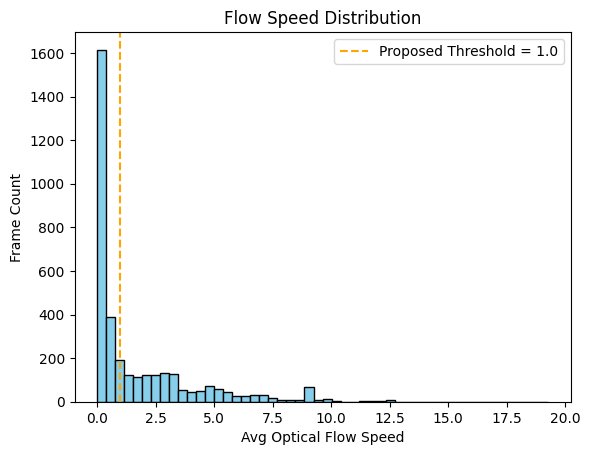

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 讀取 txt 檔案，略過第一列標頭
data = np.loadtxt(r'D:\nchu\optical_flow_avg_speed_sorted.txt', skiprows=1, encoding='utf-8')

# 只取第二欄（平均速度）
flow_speeds = data[:, 1]

# # 畫直方圖
# plt.hist(flow_speeds, bins=30, color='skyblue', edgecolor='black')
# plt.xlabel('Average Flow Speed')
# plt.ylabel('Frequency')
# plt.title('Distribution of Average Flow Speeds')
# plt.grid(True)
# plt.show()

# # 使用 KMeans 分成兩群（靜態 vs 動態）
# flow_speeds_reshaped = flow_speeds.reshape(-1, 1)
# kmeans = KMeans(n_clusters=2, random_state=0).fit(flow_speeds_reshaped)

# # 取得兩個群中心並排序
# centers = np.sort(kmeans.cluster_centers_.flatten())
# threshold_speed = centers.mean()  # 或者用兩中心的中點更穩定

# print(f"建議的 threshold_speed ≈ {threshold_speed:.3f}")

plt.hist(flow_speeds, bins=50, color='skyblue', edgecolor='black')
plt.axvline(1.0, color='orange', linestyle='--', label='Proposed Threshold = 1.0')
plt.title('Flow Speed Distribution')
plt.xlabel('Avg Optical Flow Speed')
plt.ylabel('Frame Count')
plt.legend()
plt.show()



<h1>依照速度閥值進行靜態背景與動態背景分類

In [ ]:
import os
import shutil
import numpy as np

# 設定資料夾路徑
parent_folder = r'D:\YOLOV7\project3'  # train, valid, test 路徑
static_folder = r'D:/YOLOV7/project_static'
dynamic_folder = r'D:/YOLOV7/project_dynamic'
output_file = r'D:\nchu\optical_flow_avg_speed_sorted.txt'

os.makedirs(static_folder, exist_ok=True)
os.makedirs(dynamic_folder, exist_ok=True)

data = np.loadtxt(output_file, skiprows=1, dtype={'names': ('folder', 'speed'), 'formats': ('U50', 'f4')}, encoding='utf-8')
threshold = 1.0  # 速度閾值

for split in ['train', 'valid', 'test']:
    images_folder = os.path.join(parent_folder, split, 'images')
    labels_folder = os.path.join(parent_folder, split, 'labels')

    for img_name in os.listdir(images_folder):
        if not img_name.endswith('.bmp'):
            continue
        label_name = os.path.splitext(img_name)[0] + '.txt'
        true_label_path = os.path.join(labels_folder, label_name)
        if not os.path.exists(true_label_path):
            print(f"警告：找不到真實標註 {true_label_path}，跳過")
            continue

        folder_name = os.path.splitext(img_name)[0]
        speed = next((entry[1] for entry in data if entry[0] == folder_name), None)
        if speed is None:
            print(f"警告：找不到光流速度資料 {folder_name}，跳過")
            continue

        if speed <= threshold:
            dst_folder = os.path.join(static_folder, split)
        else:
            dst_folder = os.path.join(dynamic_folder, split)

        # 確保目標資料夾存在
        os.makedirs(os.path.join(dst_folder, 'images'), exist_ok=True)
        os.makedirs(os.path.join(dst_folder, 'labels'), exist_ok=True)

        # 複製圖片
        src_img_path = os.path.join(images_folder, img_name)
        dst_img_path = os.path.join(dst_folder, 'images', img_name)
        if not os.path.exists(dst_img_path):
            shutil.copy(src_img_path, dst_img_path)

        # 複製標註檔
        src_label_path = true_label_path
        dst_label_path = os.path.join(dst_folder, 'labels', label_name)
        if not os.path.exists(dst_label_path):
            shutil.copy(src_label_path, dst_label_path)

print("完成圖片及標註檔案的靜態與動態分類與複製。")


<h1>分類yolo預測之標籤

In [ ]:
import os
import shutil
import numpy as np

# 路徑設定
pred_labels_folder = r'D:\YOLOV7\yolov7-main\runs\detect\exp13\labels'  # YOLO預測標註檔所在
static_folder = r'D:\YOLOV7\pred_labels_static'
dynamic_folder = r'D:\YOLOV7\pred_labels_dynamic'
speed_file = r'D:\nchu\optical_flow_avg_speed_sorted.txt'  # 速度檔案

threshold = 1.0  # 速度閾值，小於等於視為靜態

# 確保靜態/動態資料夾存在
os.makedirs(static_folder, exist_ok=True)
os.makedirs(dynamic_folder, exist_ok=True)

# 讀速度資料成字典 {檔名: 速度}
speed_dict = {}
with open(speed_file, 'r', encoding='utf-8') as f:
    next(f)  # 跳過標題列
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) != 2:
            continue
        file_id, speed_str = parts
        speed_dict[file_id] = float(speed_str)

# 遍歷所有標註檔
for label_file in os.listdir(pred_labels_folder):
    if not label_file.endswith('.txt'):
        continue
    file_id = os.path.splitext(label_file)[0]
    speed = speed_dict.get(file_id)
    if speed is None:
        print(f"找不到速度資料：{file_id}，跳過")
        continue

    src_path = os.path.join(pred_labels_folder, label_file)
    if speed <= threshold:
        dst_folder = static_folder
    else:
        dst_folder = dynamic_folder

    os.makedirs(dst_folder, exist_ok=True)
    dst_path = os.path.join(dst_folder, label_file)

    if not os.path.exists(dst_path):
        shutil.copy(src_path, dst_path)

print("分類完成！標註檔已依速度分到static與dynamic資料夾。")


分類完成！標註檔已依速度分到static與dynamic資料夾。


<h1>統計背景與真實物件角度差的分布

100%|██████████| 3521/3521 [21:38<00:00,  2.71it/s]


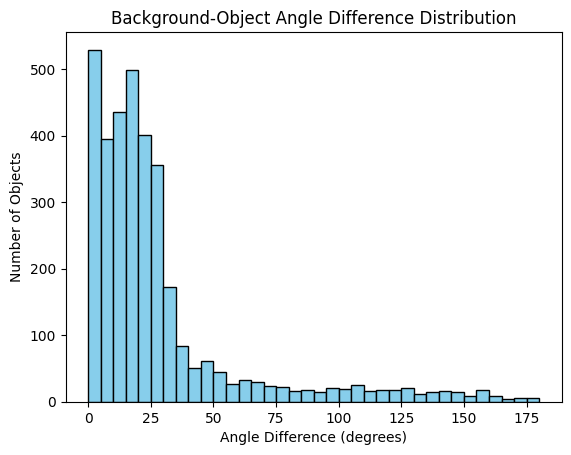

樣本數: 3449
平均角度差: 28.19 度
中位數角度差: 18.50 度
標準差: 32.83 度
最小值: 0.02 度
最大值: 179.20 度


In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 讀背景角度字典
bg_angle_file = r'D:\nchu\optical_flow_avg_direction_sorted.txt'
bg_angle_dict = {}
with open(bg_angle_file, 'r', encoding='utf-8') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) != 2:
            continue
        folder_id, angle_str = parts
        try:
            bg_angle_dict[folder_id] = float(angle_str)
        except:
            continue

parent_folder = r'D:\nchu\newmove'
real_labels_folder = r'D:\YOLOV7\labels_dynamic'  # 真實標籤
angle_diffs = []

def angle_diff(angle1, angle2):
    diff = abs(angle1 - angle2) % 360
    return min(diff, 360 - diff)

for subfolder in tqdm(os.listdir(parent_folder)):
    folder_path = os.path.join(parent_folder, subfolder)
    if not os.path.isdir(folder_path):
        continue
    if subfolder not in bg_angle_dict:
        continue
    mean_deg_bg = bg_angle_dict[subfolder]

    files = [f for f in os.listdir(folder_path) if f.startswith('frame') and f.endswith('.bmp')]
    files = sorted(files, key=lambda x: int(x[5:-4]))
    if len(files) < 2:
        continue

    img1 = cv2.imread(os.path.join(folder_path, files[0]), cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(os.path.join(folder_path, files[1]), cv2.IMREAD_GRAYSCALE)
    if img1 is None or img2 is None:
        continue

    flow = cv2.calcOpticalFlowFarneback(img1, img2, None,
                                        pyr_scale=0.5, levels=3,
                                        winsize=15, iterations=3,
                                        poly_n=5, poly_sigma=1.2, flags=0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    h, w = ang.shape

    # 讀取真實標籤
    real_label_path = os.path.join(real_labels_folder, f"{subfolder}.txt")
    if not os.path.exists(real_label_path):
        continue

    with open(real_label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, x_c, y_c, bw, bh = map(float, parts)
        x1 = int((x_c - bw / 2) * w)
        x2 = int((x_c + bw / 2) * w)
        y1 = int((y_c - bh / 2) * h)
        y2 = int((y_c + bh / 2) * h)
        x1, x2 = max(0, x1), min(w, x2)
        y1, y2 = max(0, y1), min(h, y2)

        region_angles = ang[y1:y2, x1:x2]
        if region_angles.size == 0:
            continue

        mean_x_obj = np.mean(np.cos(region_angles))
        mean_y_obj = np.mean(np.sin(region_angles))
        mean_angle_obj = np.arctan2(mean_y_obj, mean_x_obj)
        mean_deg_obj = (np.degrees(mean_angle_obj) + 360) % 360

        diff = angle_diff(mean_deg_bg, mean_deg_obj)
        angle_diffs.append(diff)

# 繪製角度差分布直方圖
plt.hist(angle_diffs, bins=36, range=(0, 180), color='skyblue', edgecolor='black')
plt.title("Background-Object Angle Difference Distribution")
plt.xlabel("Angle Difference (degrees)")
plt.ylabel("Number of Objects")
plt.show()

# 也可以印出簡單統計描述
print(f"樣本數: {len(angle_diffs)}")
print(f"平均角度差: {np.mean(angle_diffs):.2f} 度")
print(f"中位數角度差: {np.median(angle_diffs):.2f} 度")
print(f"標準差: {np.std(angle_diffs):.2f} 度")
print(f"最小值: {np.min(angle_diffs):.2f} 度")
print(f"最大值: {np.max(angle_diffs):.2f} 度")


<h1>測試在刪除背景與物件夾角小於特定值之物件標註框後準確度表現

In [ ]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# 計算 IoU 函數 (與你可視化程式相同)
def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    inter_area = max(0, min(x1 + w1, x2 + w2) - max(x1, x2)) * max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
    if inter_area == 0:
        return 0.0
    
    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area

# 路徑設定
parent_folder = r'D:\nchu\newmove'
labels_folder = r'D:\YOLOV7\yolov7-main\runs\detect\exp13\labels'  # 預測標籤
real_labels_folder = r'D:\YOLOV7\labels_dynamic'  # 真實標籤
output_labels_folder = r'D:\YOLOV7\pred_labels_dynamic_after_15degree'  # 輸出更新標籤資料夾
bg_angle_file = r'D:\nchu\optical_flow_avg_direction_sorted.txt'  # 背景平均角度檔案
angle_tolerance = 15  # 角度容差(度)

os.makedirs(output_labels_folder, exist_ok=True)

# 讀背景角度字典
bg_angle_dict = {}
with open(bg_angle_file, 'r', encoding='utf-8') as f:
    next(f)
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) != 2:
            continue
        folder_id, angle_str = parts
        try:
            bg_angle_dict[folder_id] = float(angle_str)
        except:
            continue

iou_threshold = 0.5

for subfolder in tqdm(os.listdir(parent_folder), desc="Processing folders"):
    folder_path = os.path.join(parent_folder, subfolder)
    if not os.path.isdir(folder_path):
        continue

    if subfolder not in bg_angle_dict:
        print(f"找不到背景角度: {subfolder}, 跳過")
        continue
    mean_deg_bg = bg_angle_dict[subfolder]

    files = [f for f in os.listdir(folder_path) if f.startswith('frame') and f.endswith('.bmp')]
    files = sorted(files, key=lambda x: int(x[5:-4]))
    if len(files) < 2:
        print(f"{subfolder} 影像不足，跳過")
        continue

    img1 = cv2.imread(os.path.join(folder_path, files[0]), cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(os.path.join(folder_path, files[1]), cv2.IMREAD_GRAYSCALE)
    if img1 is None or img2 is None:
        print(f"{subfolder} 影像讀取失敗，跳過")
        continue

    flow = cv2.calcOpticalFlowFarneback(img1, img2, None,
                                        pyr_scale=0.5, levels=3,
                                        winsize=15, iterations=3,
                                        poly_n=5, poly_sigma=1.2, flags=0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    h, w = ang.shape

    # 讀取真實標籤
    real_label_path = os.path.join(real_labels_folder, f"{subfolder}.txt")
    real_boxes = []
    if os.path.exists(real_label_path):
        with open(real_label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, x_c, y_c, bw, bh = map(float, parts)
                real_boxes.append((
                    x_c - bw/2, y_c - bh/2, bw, bh
                ))
    else:
        continue

    # 讀取預測標籤
    pred_label_path = os.path.join(labels_folder, f"{subfolder}.txt")
    pred_lines = []
    pred_boxes = []
    if os.path.exists(pred_label_path):
        with open(pred_label_path, 'r') as f:
            pred_lines = f.readlines()
            for line in pred_lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, x_c, y_c, bw, bh = map(float, parts)
                pred_boxes.append((
                    x_c - bw/2, y_c - bh/2, bw, bh
                ))
    else:
        continue

    # 判斷 TP 與 FP
    tp_flags = [False] * len(pred_boxes)
    for i, pbox in enumerate(pred_boxes):
        for rbox in real_boxes:
            iou = compute_iou(
                (pbox[0]*w, pbox[1]*h, pbox[2]*w, pbox[3]*h),
                (rbox[0]*w, rbox[1]*h, rbox[2]*w, rbox[3]*h)
            )
            if iou >= iou_threshold:
                tp_flags[i] = True
                break

    # 處理預測標籤，僅刪除FP且與背景角度接近的框
    new_lines = []
    for idx, line in enumerate(pred_lines):
        parts = line.strip().split()
        if len(parts) != 5:
            new_lines.append(line)
            continue
        if tp_flags[idx]:
            # TP標註直接保留
            new_lines.append(line)
            continue

        # FP標註計算光流平均角度
        _, x_c, y_c, bw, bh = map(float, parts)
        x1 = int((x_c - bw / 2) * w)
        x2 = int((x_c + bw / 2) * w)
        y1 = int((y_c - bh / 2) * h)
        y2 = int((y_c + bh / 2) * h)
        x1, x2 = max(0, x1), min(w, x2)
        y1, y2 = max(0, y1), min(h, y2)

        region_angles = ang[y1:y2, x1:x2]
        if region_angles.size == 0:
            new_lines.append(line)
            continue

        mean_x_obj = np.mean(np.cos(region_angles))
        mean_y_obj = np.mean(np.sin(region_angles))
        mean_angle_obj = np.arctan2(mean_y_obj, mean_x_obj)
        mean_deg_obj = (np.degrees(mean_angle_obj) + 360) % 360

        diff = abs(mean_deg_bg - mean_deg_obj)
        diff = min(diff, 360 - diff)

        if diff > angle_tolerance:
            new_lines.append(line)  # 角度差大保留
        else:
            print(f"刪除 FP 物件，影像 {subfolder} 物件角度 {mean_deg_obj:.1f} 與背景角度 {mean_deg_bg:.1f} 接近")

    # 輸出結果（寫入新資料夾保護原始檔案）
    output_path = os.path.join(output_labels_folder, f"{subfolder}.txt")
    with open(output_path, 'w') as f:
        f.writelines(new_lines)

print("FP 角度判斷與刪除完成！")


<h1>分類train/test

In [41]:
import os
import shutil

# 你的圖片資料夾路徑
train_image_folder = r'D:\YOLOV7\project_static_test\train\images'
test_image_folder = r'D:\YOLOV7\project_static_test\test\images'

# 標註檔原始資料夾
src_label_folder = r'D:\YOLOV7\pred_labels_static'

# 標註檔目標資料夾
train_label_folder = os.path.join(src_label_folder, 'train')
test_label_folder = os.path.join(src_label_folder, 'test')

os.makedirs(train_label_folder, exist_ok=True)
os.makedirs(test_label_folder, exist_ok=True)

# 從圖片資料夾取得檔名清單 (不含副檔名)
train_images = {os.path.splitext(f)[0] for f in os.listdir(train_image_folder) if f.lower().endswith(('.bmp','.jpg','.png'))}
test_images = {os.path.splitext(f)[0] for f in os.listdir(test_image_folder) if f.lower().endswith(('.bmp','.jpg','.png'))}

# 移動標註檔
for fname in os.listdir(src_label_folder):
    if not fname.endswith('.txt'):
        continue
    base = os.path.splitext(fname)[0]
    src_path = os.path.join(src_label_folder, fname)
    if base in train_images:
        shutil.move(src_path, os.path.join(train_label_folder, fname))
    elif base in test_images:
        shutil.move(src_path, os.path.join(test_label_folder, fname))
    else:
        print(f"{fname} 不在 train 或 test 中，跳過")

print("標註檔分類完成！")


標註檔分類完成！


<h1>使用處理後預測框計算precision跟recall

In [44]:
import os
import cv2

def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    inter_w = max(0, min(x1 + w1, x2 + w2) - max(x1, x2))
    inter_h = max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
    inter_area = inter_w * inter_h
    if inter_area == 0:
        return 0.0
    
    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area

def load_boxes(label_path, img_w, img_h):
    boxes = []
    with open(label_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_c, y_c, bw, bh = map(float, parts)
            x = (x_c - bw/2) * img_w
            y = (y_c - bh/2) * img_h
            w = bw * img_w
            h = bh * img_h
            boxes.append((x, y, w, h))
    return boxes

def calc_precision_recall_for_folder(real_dir, pred_dir, img_dir, iou_thresh=0.5):
    tp_total = 0
    fp_total = 0
    fn_total = 0

    img_w, img_h = 640, 640  # 固定尺寸

    # 遍歷真實標註檔，確保每個真實檔都被計算漏檢
    for real_file in os.listdir(real_dir):
        if not real_file.endswith('.txt'):
            continue

        base_name = os.path.splitext(real_file)[0]
        real_file_path = os.path.join(real_dir, real_file)
        pred_file_path = os.path.join(pred_dir, real_file)  # 用真實檔名對應預測檔名
        img_file = os.path.join(img_dir, base_name + '.bmp')

        real_boxes = load_boxes(real_file_path, img_w, img_h)
        
        if os.path.exists(pred_file_path):
            pred_boxes = load_boxes(pred_file_path, img_w, img_h)

            matched_real = [False] * len(real_boxes)
            matched_pred = [False] * len(pred_boxes)

            for i, pbox in enumerate(pred_boxes):
                for j, rbox in enumerate(real_boxes):
                    if not matched_real[j]:
                        iou = compute_iou(pbox, rbox)
                        if iou >= iou_thresh:
                            matched_pred[i] = True
                            matched_real[j] = True
                            tp_total += 1
                            break

            fp_total += matched_pred.count(False)
            fn_total += matched_real.count(False)
        else:
            # 預測標註檔缺失，代表沒有預測物件，FN = 全部真實框數
            fn_total += len(real_boxes)

    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
    return precision, recall

# 你的資料夾路徑
train_real_labels = r'D:\YOLOV7\project4\train\labels'
train_pred_labels = r'D:\YOLOV7\pred_labels_merge_s_d_15\train'
train_images = r'D:\YOLOV7\project4\train\images'

test_real_labels = r'D:\YOLOV7\project4\test\labels'
test_pred_labels = r'D:\YOLOV7\pred_labels_merge_s_d_15\test'
test_images = r'D:\YOLOV7\project4\test\images'

train_prec, train_rec = calc_precision_recall_for_folder(train_real_labels, train_pred_labels, train_images)
test_prec, test_rec = calc_precision_recall_for_folder(test_real_labels, test_pred_labels, test_images)

print(f"Train Precision: {train_prec:.4f}, Recall: {train_rec:.4f}")
print(f"Test Precision: {test_prec:.4f}, Recall: {test_rec:.4f}")

# 輸出結果到檔案
output_path = r'D:\YOLOV7\pred_labels_merge_s_d_15\precision_recall_results.txt'

with open(output_path, 'w', encoding='utf-8') as f:
    f.write("資料集\tPrecision\tRecall\n")
    f.write(f"Train\t{train_prec:.4f}\t{train_rec:.4f}\n")
    f.write(f"Test\t{test_prec:.4f}\t{test_rec:.4f}\n")

print(f"計算完成，結果已儲存至：{output_path}")


Train Precision: 0.9711, Recall: 0.9541
Test Precision: 0.8382, Recall: 0.6565
計算完成，結果已儲存至：D:\YOLOV7\pred_labels_merge_s_d_15\precision_recall_results.txt


In [ ]:
import os
import cv2

def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    inter_w = max(0, min(x1 + w1, x2 + w2) - max(x1, x2))
    inter_h = max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
    inter_area = inter_w * inter_h
    if inter_area == 0:
        return 0.0
    
    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area

def load_boxes(label_path, img_w, img_h):
    boxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, x_c, y_c, bw, bh = map(float, parts)
            x = (x_c - bw/2) * img_w
            y = (y_c - bh/2) * img_h
            w = bw * img_w
            h = bh * img_h
            boxes.append((x, y, w, h))
    return boxes

def calc_metrics_for_folder(real_dir, pred_dir, img_dir, iou_thresh=0.5):
    tp = fp = fn = 0
    img_w, img_h = 640, 640  # 固定尺寸

    for real_file in os.listdir(real_dir):
        if not real_file.endswith('.txt'):
            continue

        base = os.path.splitext(real_file)[0]
        real_boxes = load_boxes(os.path.join(real_dir, real_file), img_w, img_h)
        pred_path = os.path.join(pred_dir, real_file)

        if os.path.exists(pred_path):
            pred_boxes = load_boxes(pred_path, img_w, img_h)

            matched_real = [False] * len(real_boxes)
            matched_pred = [False] * len(pred_boxes)

            # 計算 TP
            for i, p in enumerate(pred_boxes):
                for j, r in enumerate(real_boxes):
                    if not matched_real[j] and compute_iou(p, r) >= iou_thresh:
                        matched_pred[i] = True
                        matched_real[j] = True
                        tp += 1
                        break

            # 剩下的 False 就是 FP 與 FN
            fp += matched_pred.count(False)
            fn += matched_real.count(False)
        else:
            # 預測檔缺失：全部算 FN
            fn += len(real_boxes)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return tp, fp, fn, precision, recall, f1

# 資料夾路徑設定
train_real_labels = r'D:\YOLOV7\project_dynamic_test\train\labels'
train_pred_labels = r'D:\YOLOV7\pred_labels_dynamic_after_15degree\train'
train_images     = r'D:\YOLOV7\project_dynamic_test\train\images'

test_real_labels  = r'D:\YOLOV7\project_dynamic_test\test\labels'ㄌ
test_pred_labels  = r'D:\YOLOV7\pred_labels_dynamic_after_15degree\test'
test_images      = r'D:\YOLOV7\project_dynamic_test\test\images'

# 計算指標
train_tp, train_fp, train_fn, train_prec, train_rec, train_f1 = calc_metrics_for_folder(
    train_real_labels, train_pred_labels, train_images)
test_tp,  test_fp,  test_fn,  test_prec,  test_rec,  test_f1  = calc_metrics_for_folder(
    test_real_labels,  test_pred_labels,  test_images)

# 印出結果
print(f"Train → TP: {train_tp}, FP: {train_fp}, FN: {train_fn}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}, F1: {train_f1:.4f}")
print(f"Test  → TP: {test_tp},  FP: {test_fp},  FN: {test_fn},  Precision: {test_prec:.4f},  Recall: {test_rec:.4f},  F1: {test_f1:.4f}")

# 寫入檔案
output_path = r'D:\YOLOV7\pred_labels_dynamic_after_15degree\all_results.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write("Dataset\tTP\tFP\tFN\tPrecision\tRecall\tF1\n")
    f.write(f"Train\t{train_tp}\t{train_fp}\t{train_fn}\t{train_prec:.4f}\t{train_rec:.4f}\t{train_f1:.4f}\n")
    f.write(f"Test\t{test_tp}\t{test_fp}\t{test_fn}\t{test_prec:.4f}\t{test_rec:.4f}\t{test_f1:.4f}\n")

print(f"計算完成，結果已儲存至：{output_path}")


Train → TP: 2881, FP: 108, FN: 234, Precision: 0.9639, Recall: 0.9249, F1: 0.9440
Test  → TP: 47,  FP: 12,  FN: 287,  Precision: 0.7966,  Recall: 0.1407,  F1: 0.2392
計算完成，結果已儲存至：D:\YOLOV7\pred_labels_dynamic_after_15degree\all_results.txt
